# Trabajo Práctico 4: Aprendizaje No-Supervisado

In [1]:
import torch

from src.pca import fit_pca, transform_pca, reconstruct_pca
%load_ext autoreload
%autoreload 2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List
from src.utils import DATA_PATH, RANDOM_SEED, train_val_split, df_to_np, standardize, INPUT_SIZE, analyze_cluster_homogeneity
from src.plots import plot_images, plot_class_distribution, plot_images_by_class, plot_explained_variance, plot_reconstruction_comparison, plot_clusteres_2d, plot_silhouette_comparison, plot_elbow_method, plot_cluster_composition, plot_cluster_entropy, plot_eigenvectors
from src.autoencoder import ModelConfig, compare_models, Autoencoder, prepare_autoencoder_data, train_autoencoder
from src.metrics import mse, silhouette_score
from src.kmeans import kmeans
from src.gmm import gmm

np.random.seed(RANDOM_SEED)

## 1. Inspección de los datos

**a) Implementar una función que pueda graficar un número
   arbitrario de imágenes del dataset. Mostrar un ejemplo
   de un gráfico con 15 imágenes seleccionadas de manera
  aleatoria. Esta función va a ser necesaria a lo largo
  de todo el trabajo, por lo que se deberá ir adaptando
  de acuerdo a las necesidades que vayan surgiendo.**

In [2]:
df = pd.read_csv(DATA_PATH)

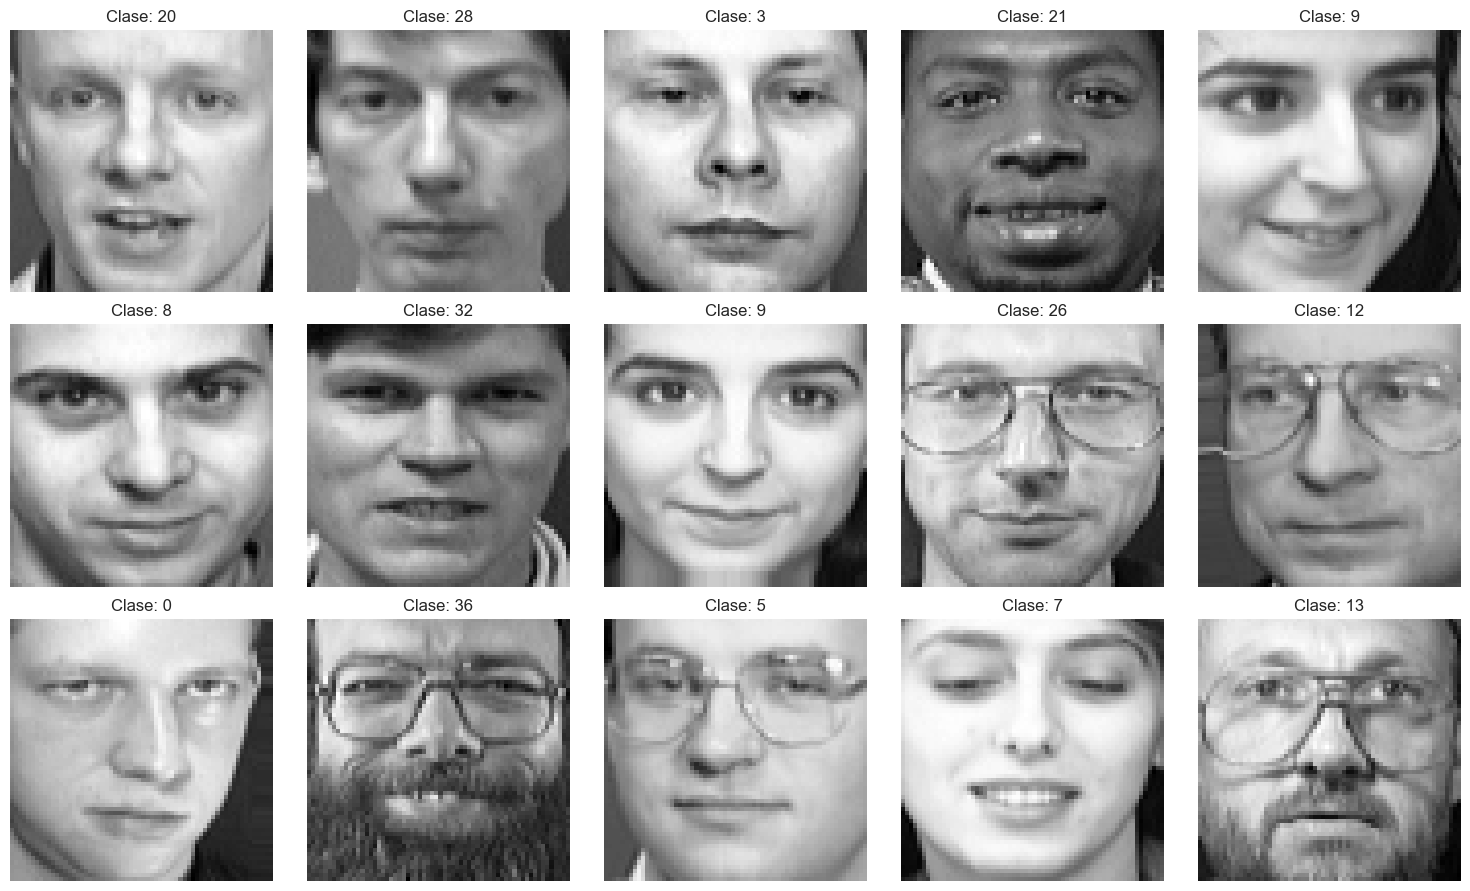

In [3]:
plot_images(df, n=15, ncols=5, filename="1_initial_faces")

**b) Realizar un analisis exploratorio enfocado en
  la distribución de clases en los datos. Para
  tener una mejor noción de la variabilidad de las
  muestras, graficar muestras agrupadas por clase,
  para al menos 5 clases.**

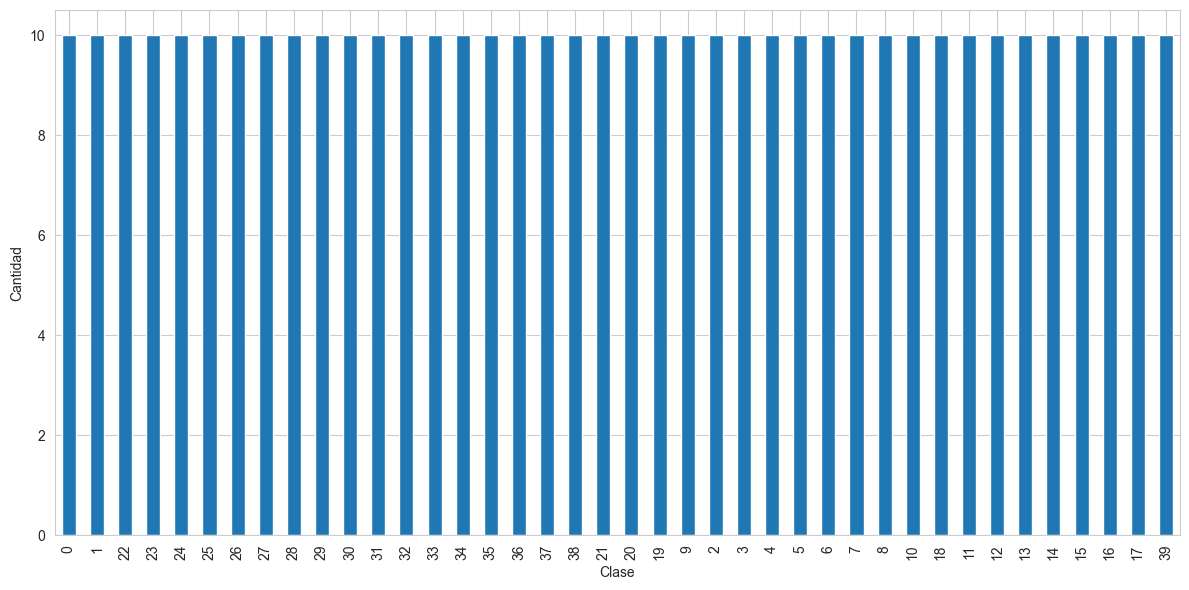

In [4]:
plot_class_distribution(df, figsize=(12,6), filename="2_class_distribution")

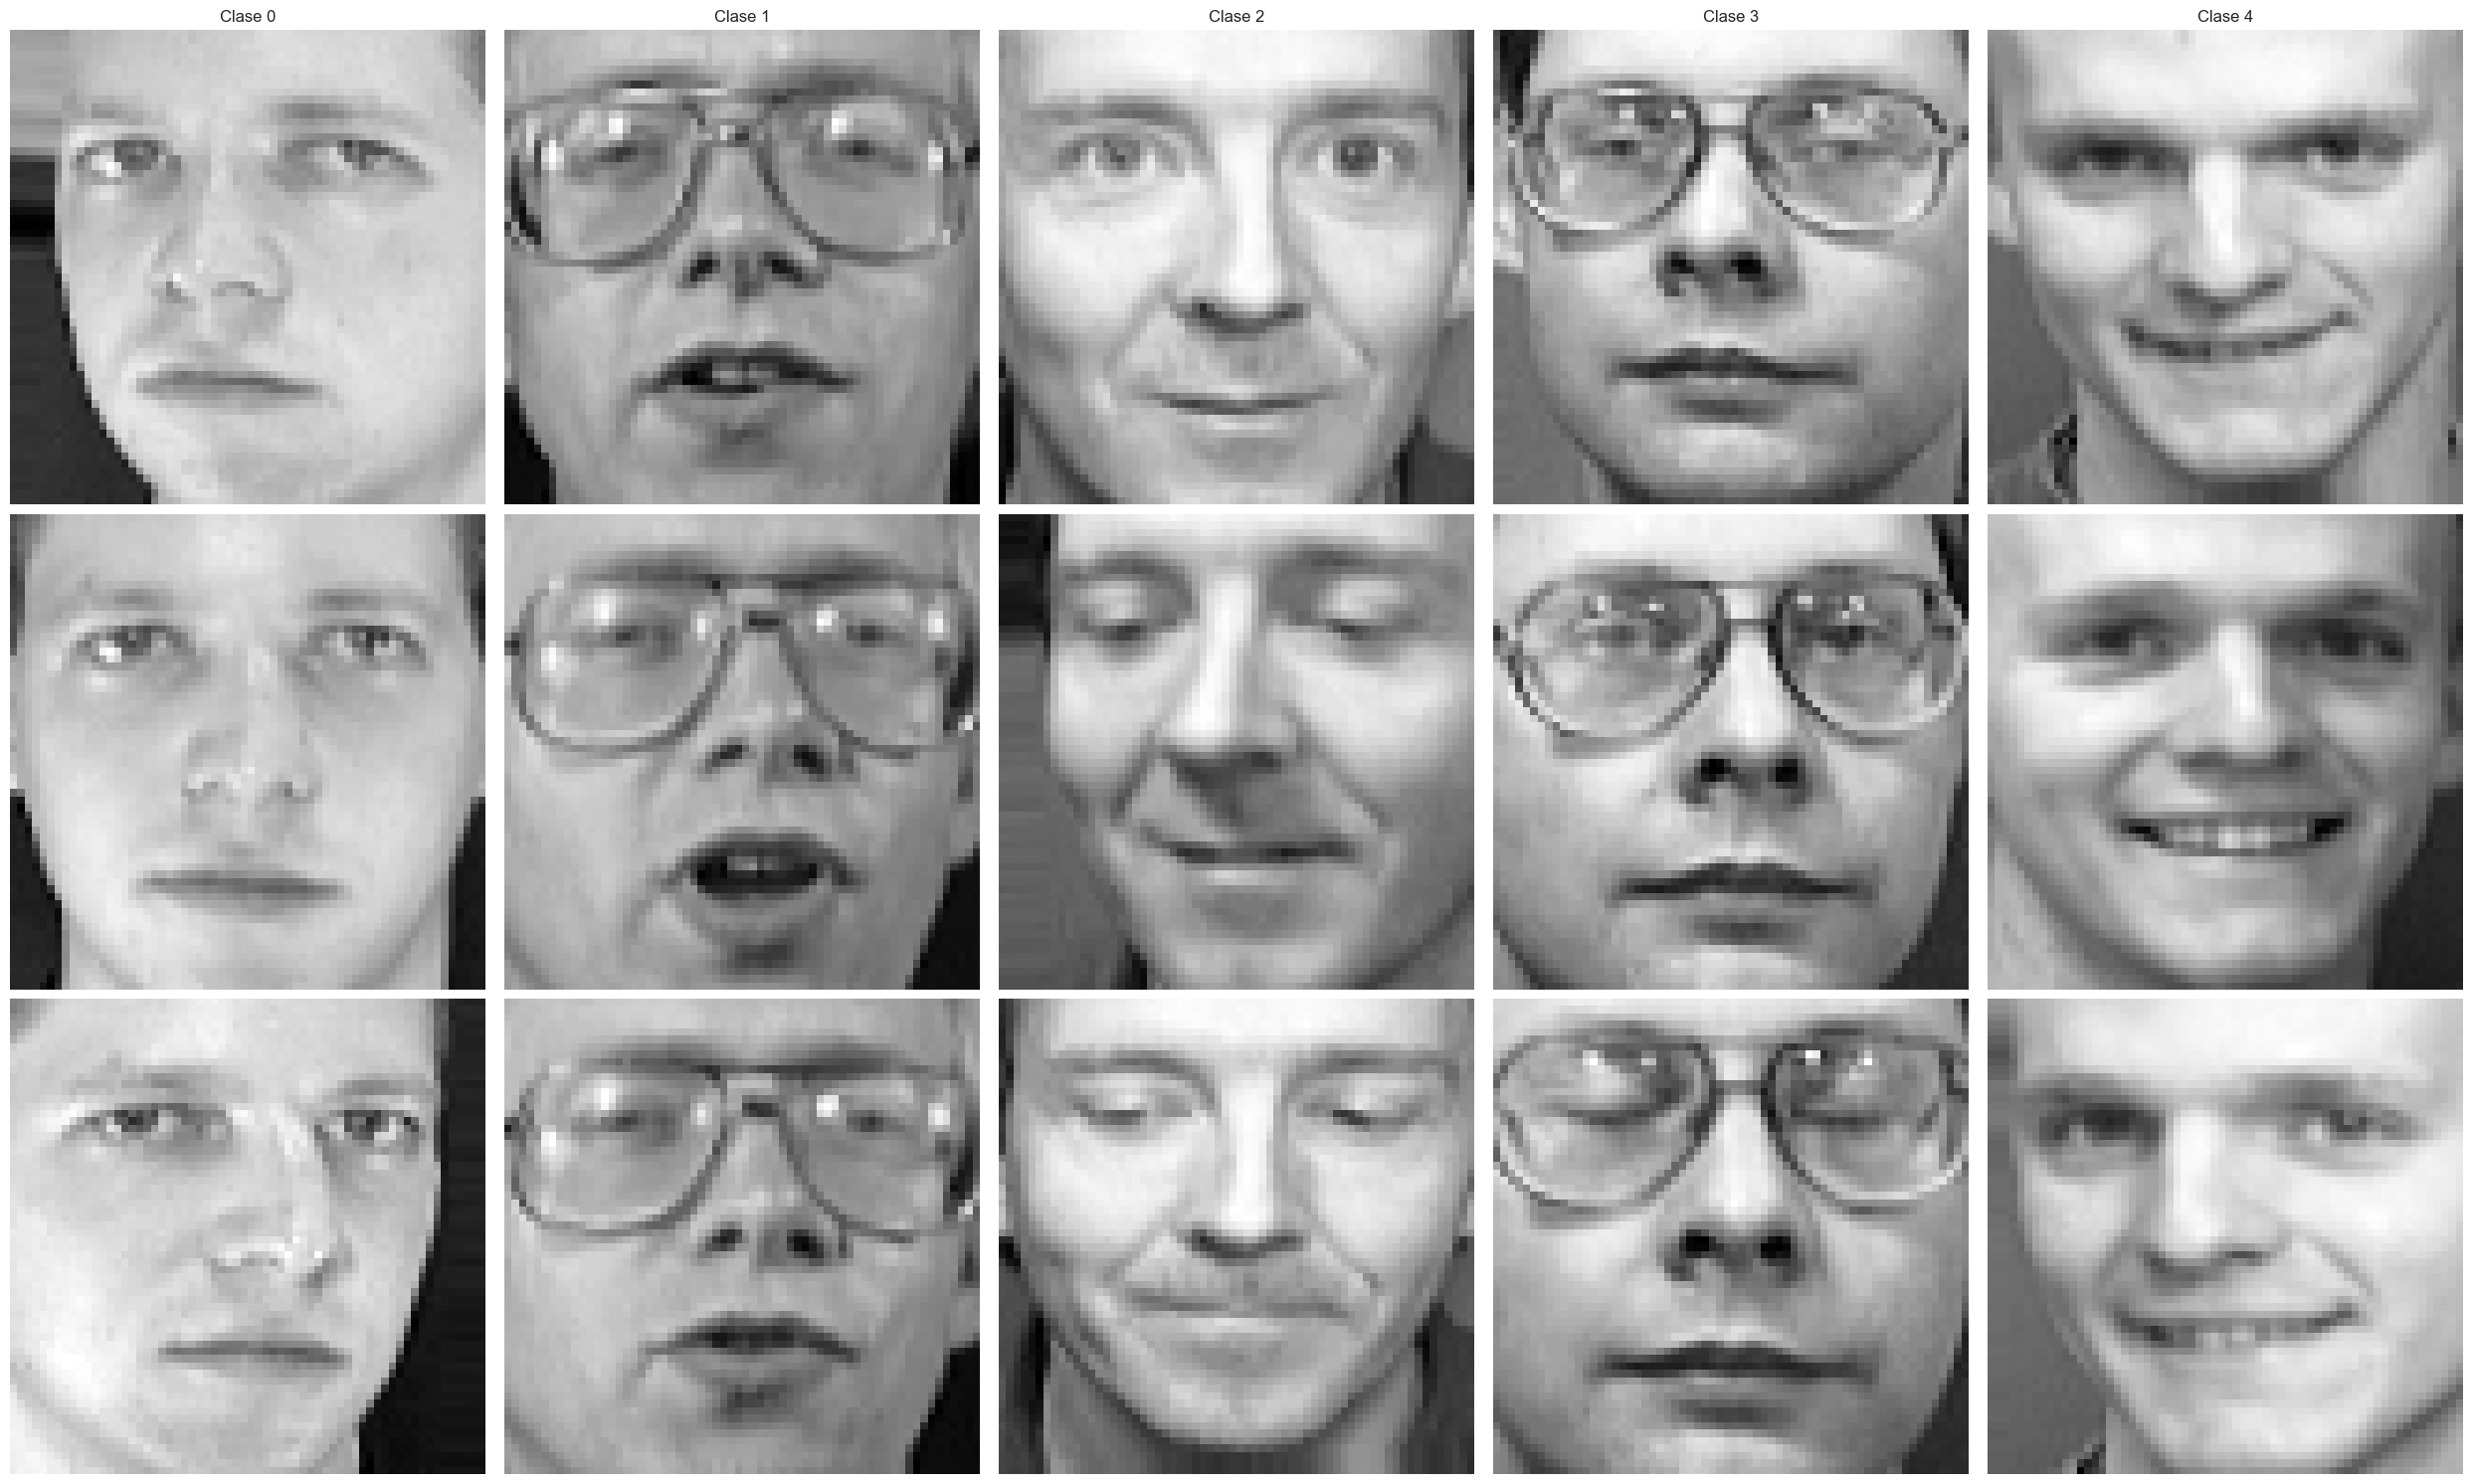

In [5]:
plot_images_by_class(df, n_classes=5, n_per_class=3, filename="3_initial_faces_by_class")

  **c) Realizar un split de datos estratificado para
  conformar un conjunto de entrenamiento y otro de
  evaluación, en donde los datos de evaluación sean
   el 20 % del total.**

In [6]:
df_train, df_val = train_val_split(df, val_size=0.2)
df_train.shape

(320, 4097)

## 2. Reducción de dimensionalidad

**a) Implementar una función para estandarizar los
  datos, y otra para realizar Principal Component
  Analysis (PCA). Estandarizar y aplicar PCA sobre
  los datos de entrenamiento. Con la transformacion
   aprendida previamente reducir la dimensionalidad
   de los datos de evaluacion.**

In [7]:
# primero convertimos a numpy
X_train, y_train = df_to_np(df_train)

# estandarizamos
X_train_std, X_train_mu, X_train_sigma = standardize(X_train)

# calculamos:
# W = autovectores como columnas
# lambdas = autovalores
# varianza explicada por cada componente principal
lambdas, W, explained_variance_ratios = fit_pca(X_train_std)

# transformamos sin reducir dimensionalidad
Z_full = transform_pca(X_train_std, W)

b) Realizar un gráfico que muestre la varianza
  explicada acumulada en función del número de
  componentes. Conservar el número de componentes
  que aseguren explicar el 90 % de la varianza de
  los datos. Utilizando la función aprendida en el
  punto 1.a), realizar un gráfico comparativo entre
   las imágenes originales y la reconstrucción
  partiendo del número de componentes determinado
  anteriormente.

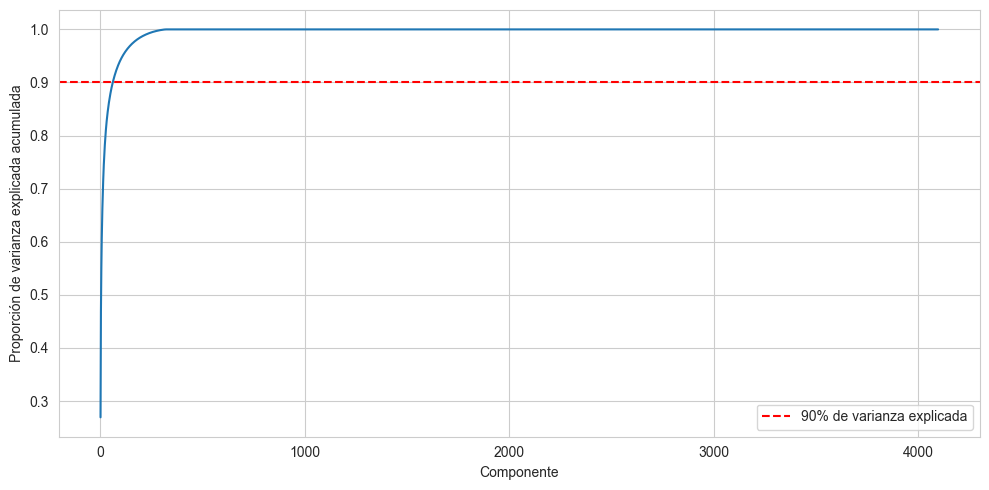

In [8]:
plot_explained_variance(explained_variance_ratios, filename="4_explained_variance")

In [9]:
threshold_component = np.argmax(np.cumsum(explained_variance_ratios) >= 0.90) + 1
print(f"Las primeras {threshold_component} componentes principales explican el 90% de la varianza")

Las primeras 61 componentes principales explican el 90% de la varianza


In [10]:
LATENT_SIZE = int(threshold_component)
Z_reduced = transform_pca(X_train_std, W, LATENT_SIZE)
X_reconstructed = reconstruct_pca(Z_reduced, W, X_train_mu, X_train_sigma, LATENT_SIZE)

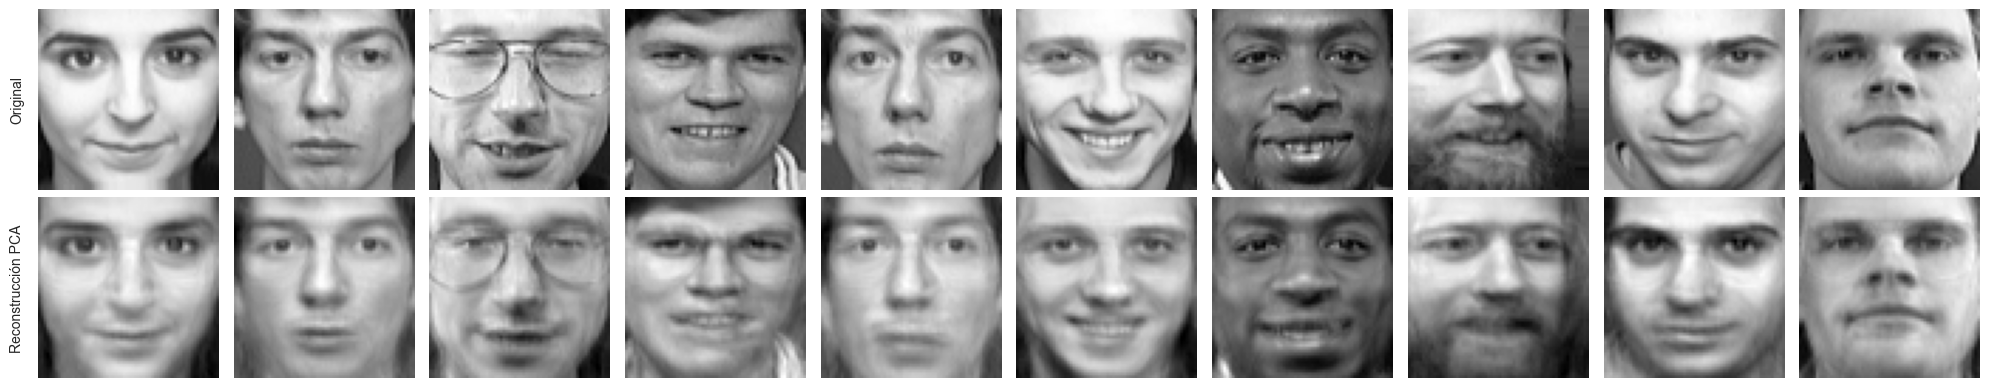

In [11]:
plot_reconstruction_comparison(X_train, X_reconstructed, n_images=10, filename="5_reconstruction_comparison")

In [12]:
mse_pca = mse(X_train, X_reconstructed)
print(f"El error de reconstrucción del PCA es: {mse_pca}")

El error de reconstrucción del PCA es: 0.00196018237003768


Bonus: Graficar los 5 autovectores principales

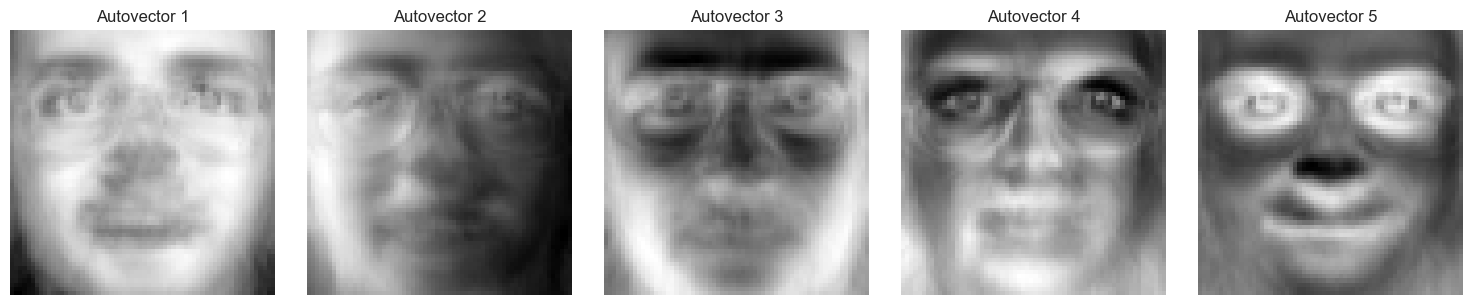

In [13]:
plot_eigenvectors(W, n_components=5, filename="6_eigenvectors")

**c) Entrenar un modelo de autoencoder
  deterministico (AE) utilizando la librería
  PyTorch para armar y entrenar las redes
  neuronales involucradas (la red de encoder y la
  de decoder). Para hacer una comparacion justa, la
   dimension latente debe ser la misma que la
  obtenida en el PCA. Recuerde dividir el conjunto
  de datos en dos subconjuntos: entrenamiento y
  validación, los mismos utilizados para el PCA. El
   subconjunto de entrenamiento se empleará para
  entrenar el AE, mientras que el de validación
  servirá para ajustar los hiperparámetros
  (regularizacion, arquitectura o lo que considere)
   y evaluar el error de reconstrucción.**

In [14]:
X_val, y_val = df_to_np(df_val)
X_val_std, _, _ = standardize(X_val, X_train_mu, X_train_sigma) # usamos los mu y sigma que obtuvimos de train

# Probamos varias arquitecturas  & dropouts
configs: List[ModelConfig] = [
    ModelConfig(
        encoder_layers=[512],
        latent_size=LATENT_SIZE,
        decoder_layers=[512],
        dropout=0.0,
        lr=0.001,
        name="mini",
    ),
    ModelConfig(
        encoder_layers=[1024],
        latent_size=LATENT_SIZE,
        decoder_layers=[1024],
        dropout=0.0,
        lr=0.001,
        name="narrow_shallow_no_dropout",
    ),
    ModelConfig(
        encoder_layers=[2048],
        latent_size=LATENT_SIZE,
        decoder_layers=[2048],
        dropout=0.1,
        lr=0.0001,
        name="wide_shallow_dropout_01",
    ),
    ModelConfig(
        encoder_layers=[3072],
        latent_size=LATENT_SIZE,
        decoder_layers=[3072],
        dropout=0.2,
        lr=0.001,
        name="ultrawide_shallow_dropout_01",
    ),
    ModelConfig(
        encoder_layers=[2048, 1024, 512],
        latent_size=LATENT_SIZE,
        decoder_layers=[512, 1024, 2048],
        dropout=0.2,
        lr=0.001,
        name="wide_deep_dropout_02",
    ),
    ModelConfig(
        encoder_layers=[2048, 512],
        latent_size=LATENT_SIZE,
        decoder_layers=[512, 2048],
        dropout=0.1,
        lr=0.001,
        name="wide_shallow_dropout_01",
    ),
    ModelConfig(
        encoder_layers=[1024, 256],
        latent_size=LATENT_SIZE,
        decoder_layers=[256, 1024],
        dropout=0.0,
        lr=0.001,
        name="ultranarrow_no_dropout",
    ),
    ModelConfig(
        encoder_layers=[3072, 2048],
        latent_size=LATENT_SIZE,
        decoder_layers=[2048, 3072],
        dropout=0.2,
        lr=0.001,
        name="ultrawide_shallow_dropout_03",
    ),
    ModelConfig(
        encoder_layers=[3072, 2048, 1024, 512],
        latent_size=LATENT_SIZE,
        decoder_layers=[512, 1024, 2048, 3072],
        dropout=0.3,
        lr=0.005,
        name="ultrawide_deep_dropout_04",

    )
]

results, best_model = compare_models(configs, X_train_std, X_val_std, epochs=500, input_size=INPUT_SIZE)

Training model: mini
Epoch 1/500, Train Loss: 1.0035, Val Loss: 1.1362
Epoch 11/500, Train Loss: 0.5668, Val Loss: 0.5633
Epoch 21/500, Train Loss: 0.4206, Val Loss: 0.4401
Epoch 31/500, Train Loss: 0.3294, Val Loss: 0.3627
Epoch 41/500, Train Loss: 0.2670, Val Loss: 0.3121
Epoch 51/500, Train Loss: 0.2228, Val Loss: 0.2805
Epoch 61/500, Train Loss: 0.1909, Val Loss: 0.2602
Epoch 71/500, Train Loss: 0.1659, Val Loss: 0.2454
Epoch 81/500, Train Loss: 0.1463, Val Loss: 0.2350
Epoch 91/500, Train Loss: 0.1289, Val Loss: 0.2260
Epoch 101/500, Train Loss: 0.1150, Val Loss: 0.2203
Epoch 111/500, Train Loss: 0.1067, Val Loss: 0.2183
Epoch 121/500, Train Loss: 0.0937, Val Loss: 0.2132
Epoch 131/500, Train Loss: 0.0845, Val Loss: 0.2109
Epoch 141/500, Train Loss: 0.0765, Val Loss: 0.2092
Epoch 151/500, Train Loss: 0.0696, Val Loss: 0.2080
Epoch 161/500, Train Loss: 0.0647, Val Loss: 0.2088
Epoch 171/500, Train Loss: 0.0588, Val Loss: 0.2077
Epoch 181/500, Train Loss: 0.0533, Val Loss: 0.2076
Ep

In [15]:
autoencoder = results[best_model]["model"]

autoencoder.eval()
with torch.no_grad():
    X_encoded_ae = autoencoder.encode(X_train_std, numpy=True)
    X_reconstructed_ae = autoencoder.reconstruct(X_encoded_ae, sigma=X_train_sigma, mu=X_train_mu)

    mse_ae = mse(X_train, X_reconstructed_ae)
    print(f"El error de reconstrucción del AE es: {mse_ae}")


El error de reconstrucción del AE es: 0.0005688404167793423


 **d) Una vez desarrollado el AE, compare la calidad de las imágenes reconstruidas con
  las obtenidas mediante PCA en el inciso anterior, utilizando 10 imagenes tomadas
  aleatoriamente del conjunto de validación del AE.**

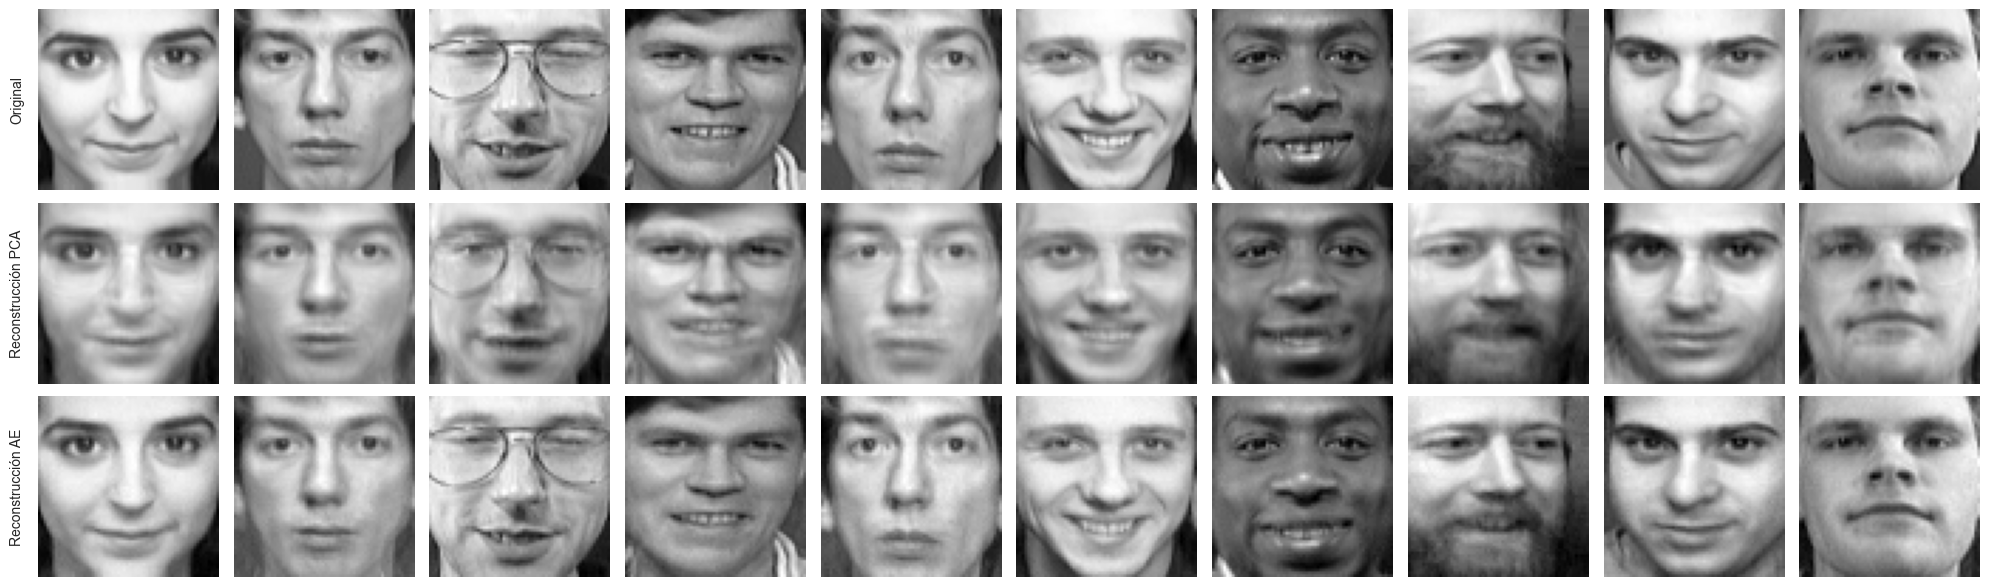

In [16]:
plot_reconstruction_comparison(X_train, X_reconstructed, X_reconstructed_ae, n_images=10, filename="7_reconstruction_comparison_ae")

 **e) Para los siguientes puntos, en lugar de trabajar con las imágenes originales vamos
  a trabajar con su versión de menor dimensionalidad en el espacio latente del PCA y AE
  obtenida en el inciso anterior para acelerar el procesamiento. Aplique la
  transformación para todos los datos, tanto de entrenamiento como de evaluación usando
  la transformacion aprendida con los datos de entrenamiento.**


In [17]:
autoencoder.eval()
with torch.no_grad():
    Z_train = autoencoder.encode(X_train_std, numpy=True)
    Z_val = autoencoder.encode(X_val_std, numpy=True)

## 3. Clustering
**a) Desarrollar una funcion que implemente el
  algoritmo k-Means. Probar con valores de K
  dentro del rango de [5, 20].**


In [18]:
kmeans_results = {}

K_RANGE = range(5, 21)

for i in K_RANGE:
    centroids, assignments, losses = kmeans(Z_train, i, max_iters=500)
    kmeans_results[i] = {
        "centroids": centroids,
        "assignments": assignments,
        "losses": losses,
        "silhouette_score": silhouette_score(Z_train, assignments),
    }

Iteration 0: loss = 1741.7643714094302
Iteration 10: loss = 1513.6267099492527
Converged at iteration 12
Iteration 0: loss = 1671.7603991667813
Iteration 10: loss = 1489.3649902095517
Iteration 20: loss = 1434.678069891833
Converged at iteration 23
Iteration 0: loss = 1538.3502952708816
Iteration 10: loss = 1392.223821007122
Converged at iteration 19
Iteration 0: loss = 1484.91678945272
Iteration 10: loss = 1315.7119595784868
Converged at iteration 11
Iteration 0: loss = 1448.4708718621848
Iteration 10: loss = 1291.2699147398635
Converged at iteration 15
Iteration 0: loss = 1398.4161873574617
Iteration 10: loss = 1259.031547903702
Iteration 20: loss = 1222.3587333086875
Converged at iteration 23
Iteration 0: loss = 1341.4870491686117
Converged at iteration 7
Iteration 0: loss = 1335.7603539695383
Converged at iteration 9
Iteration 0: loss = 1313.8298067524358
Converged at iteration 9
Iteration 0: loss = 1291.2897148773623
Iteration 10: loss = 1109.400260327536
Converged at iteration 12

**b) Desarrollar una funcion que implemente el
  algoritmo GMM. Probar con valores de K dentro del
   rango de [5, 20]**

In [19]:
gmm_results = {}

for i in K_RANGE:
    means, covariances, priors, assignments, log_likelihoods = gmm(Z_train, i, max_iters=500, tolerance=10)
    gmm_results[i] = {
        "means": means,
        "covariances": covariances,
        "priors": priors,
        "assignments": assignments,
        "log_likelihoods": log_likelihoods,
        "silhouette_score": silhouette_score(Z_train, assignments),
    }


Iteration 0: loss = 1741.7643714094302
Iteration 10: loss = 1513.6267099492527
Converged at iteration 12
Iteration 0: log likelihood = -7368.272297580908
Converged at iteration 1
Iteration 0: loss = 1671.7603991667813
Iteration 10: loss = 1489.3649902095517
Iteration 20: loss = 1434.678069891833
Converged at iteration 23
Iteration 0: log likelihood = -7368.272297580908
Converged at iteration 1
Iteration 0: loss = 1538.3502952708816
Iteration 10: loss = 1392.223821007122
Converged at iteration 19
Iteration 0: log likelihood = -7368.272297580908
Converged at iteration 1
Iteration 0: loss = 1484.91678945272
Iteration 10: loss = 1315.7119595784868
Converged at iteration 11
Iteration 0: log likelihood = -7368.272297580825
Converged at iteration 1
Iteration 0: loss = 1448.4708718621848
Iteration 10: loss = 1291.2699147398635
Converged at iteration 15
Iteration 0: log likelihood = -7368.272297580135
Converged at iteration 1
Iteration 0: loss = 1398.4161873574617
Iteration 10: loss = 1259.0315

**3c) Analizar el desempeño para distintos valores de
  K. Utilizar el método de ganancias decrecientes,
  junto con el método de Silhouette score. Graficar
   tanto la ganancia marginal como el valor de
  Silhouette score en función de K. ¿Qué se puede
  concluir sobre K observando estas curvas? ¿Cómo
  se relaciona el numero de K encontrado con el
  número de clases presentes en los datos?
  Justificar**

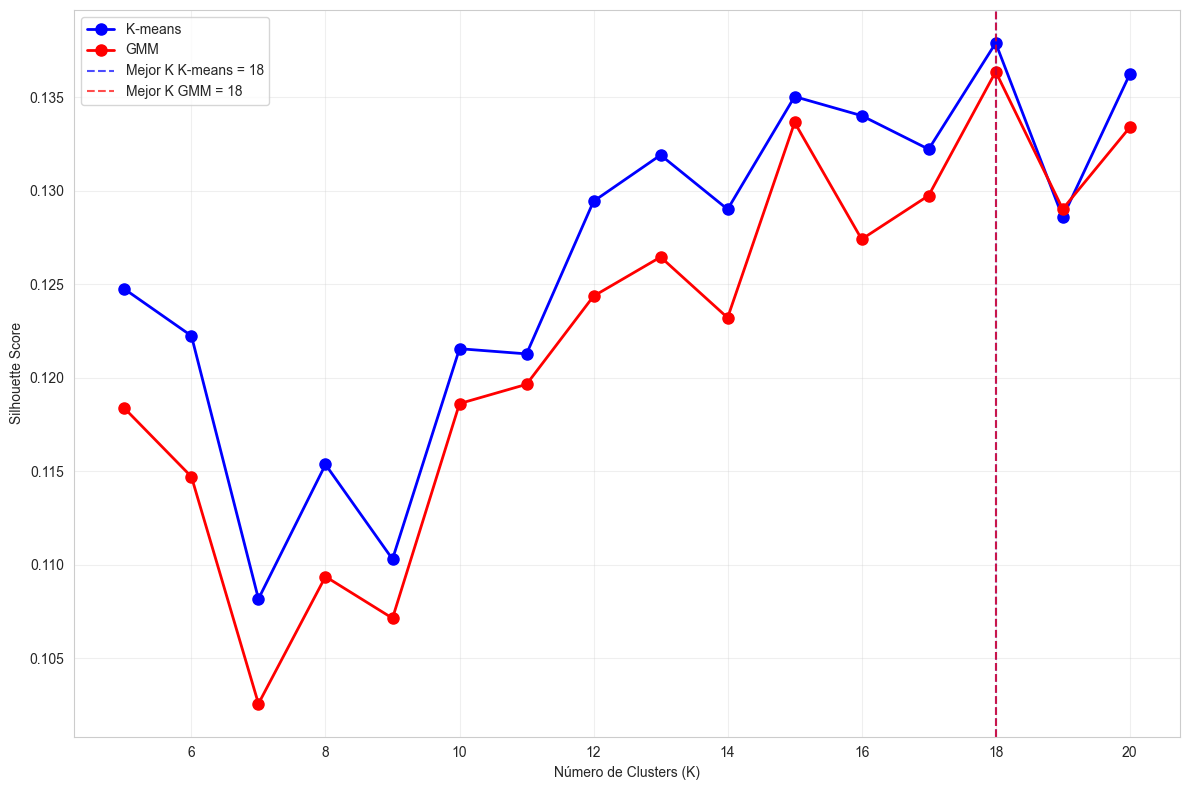

In [20]:
plot_silhouette_comparison(kmeans_results, gmm_results, filename="8_silhouette_comparison")


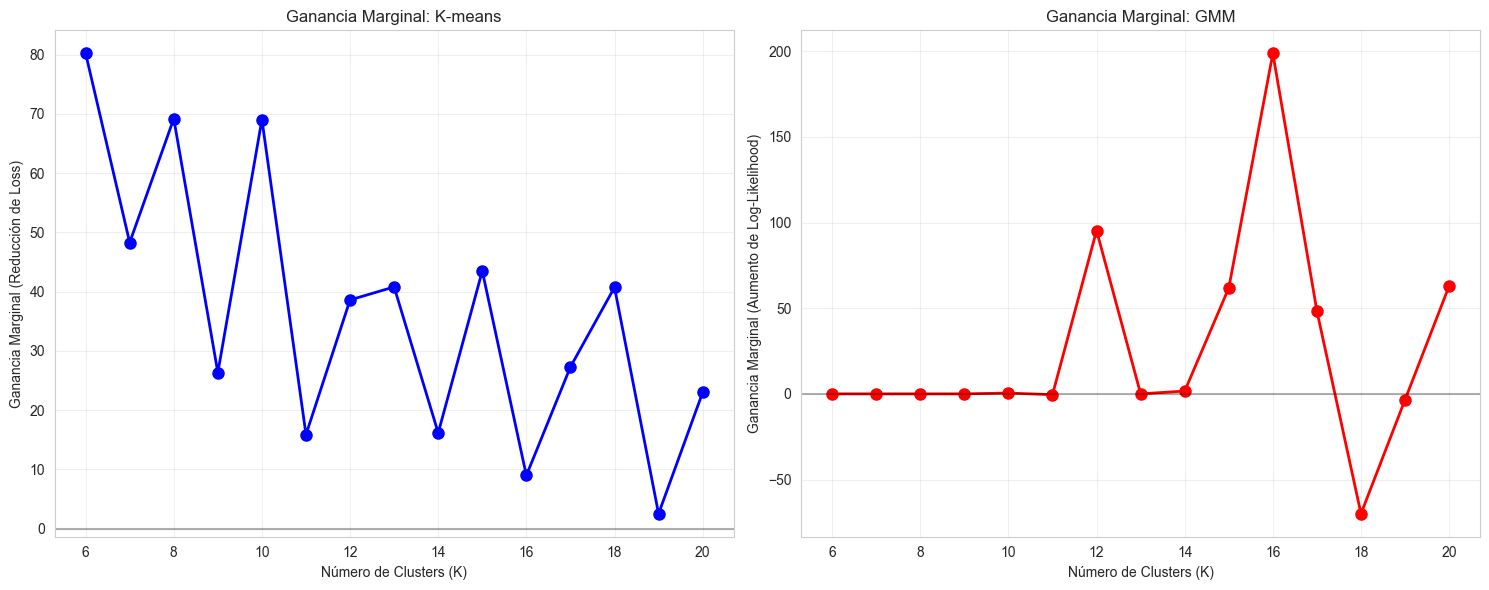

In [21]:
plot_elbow_method(kmeans_results, gmm_results, figsize=(15, 6), filename="9_marginal_gains")

**d)Del mejor valor de K resultante del análisis anterior graficar las
   muestras de cada cluster en 2D utilizando la función de reduccion
  dimensional aprendida en el punto 1. ¿Qué puede decir de la calidad
   de los clusters de acuerdo a la cantidad de muestras que agrupa y
  la homogeneidad de clases en cada cluster? Realizar los
  gráficos/tablas/análisis que crea conveniente para fundamentar su
  respuesta.**

In [22]:
# Entrenamos un autoencoder con los mismos parámetros que la mejor configuración que obtuvimos, pero con dimension latente = 2
reducer_2d_config = ModelConfig(
    encoder_layers=[INPUT_SIZE, 2048],
    latent_size=2,
    decoder_layers=[2048, INPUT_SIZE],
    dropout=0.1,
    lr=0.0001,
    name="2d_reducer",
)

reducer_2d = Autoencoder(
    encoder_layers=reducer_2d_config["encoder_layers"],
    latent_size=reducer_2d_config["latent_size"],
    decoder_layers=reducer_2d_config["decoder_layers"],
    dropout=reducer_2d_config["dropout"],
)

train_loader, val_loader = prepare_autoencoder_data(X_train_std, X_val_std)
train_autoencoder(reducer_2d, train_loader, val_loader, epochs=500, lr=reducer_2d_config["lr"], patience=30, min_delta=0.0001)

Epoch 1/500, Train Loss: 1.0296, Val Loss: 1.1004
Epoch 11/500, Train Loss: 0.8657, Val Loss: 0.8459
Epoch 21/500, Train Loss: 0.6534, Val Loss: 0.6535
Epoch 31/500, Train Loss: 0.6112, Val Loss: 0.6190
Epoch 41/500, Train Loss: 0.5972, Val Loss: 0.6094
Epoch 51/500, Train Loss: 0.5906, Val Loss: 0.6043
Epoch 61/500, Train Loss: 0.5827, Val Loss: 0.5993
Epoch 71/500, Train Loss: 0.5767, Val Loss: 0.5960
Epoch 81/500, Train Loss: 0.5721, Val Loss: 0.5929
Epoch 91/500, Train Loss: 0.5677, Val Loss: 0.5906
Epoch 101/500, Train Loss: 0.5637, Val Loss: 0.5885
Epoch 111/500, Train Loss: 0.5598, Val Loss: 0.5865
Epoch 121/500, Train Loss: 0.5560, Val Loss: 0.5845
Epoch 131/500, Train Loss: 0.5523, Val Loss: 0.5826
Epoch 141/500, Train Loss: 0.5486, Val Loss: 0.5809
Epoch 151/500, Train Loss: 0.5451, Val Loss: 0.5795
Epoch 161/500, Train Loss: 0.5414, Val Loss: 0.5781
Epoch 171/500, Train Loss: 0.5376, Val Loss: 0.5769
Epoch 181/500, Train Loss: 0.5335, Val Loss: 0.5757
Epoch 191/500, Train Lo

([1.0296368598937988,
  1.0885884761810303,
  1.022621989250183,
  1.0456807613372803,
  1.0307451486587524,
  1.0055809020996094,
  0.9889100790023804,
  0.96917325258255,
  0.9427396655082703,
  0.9069643020629883,
  0.8657094836235046,
  0.8259353637695312,
  0.7914355993270874,
  0.7628187537193298,
  0.7371498346328735,
  0.7149391174316406,
  0.69663405418396,
  0.6832942962646484,
  0.6730095744132996,
  0.6637855768203735,
  0.6533626317977905,
  0.643020749092102,
  0.6354061961174011,
  0.630028247833252,
  0.6262143850326538,
  0.6229599118232727,
  0.6188341379165649,
  0.6157602071762085,
  0.6150606870651245,
  0.6140506863594055,
  0.6111675500869751,
  0.6082061529159546,
  0.6070706248283386,
  0.6063984632492065,
  0.6048520803451538,
  0.6027649641036987,
  0.601466953754425,
  0.6007581949234009,
  0.5993010401725769,
  0.5980187058448792,
  0.5971769690513611,
  0.5962614417076111,
  0.5959024429321289,
  0.5986892580986023,
  0.6036407351493835,
  0.59646582603454

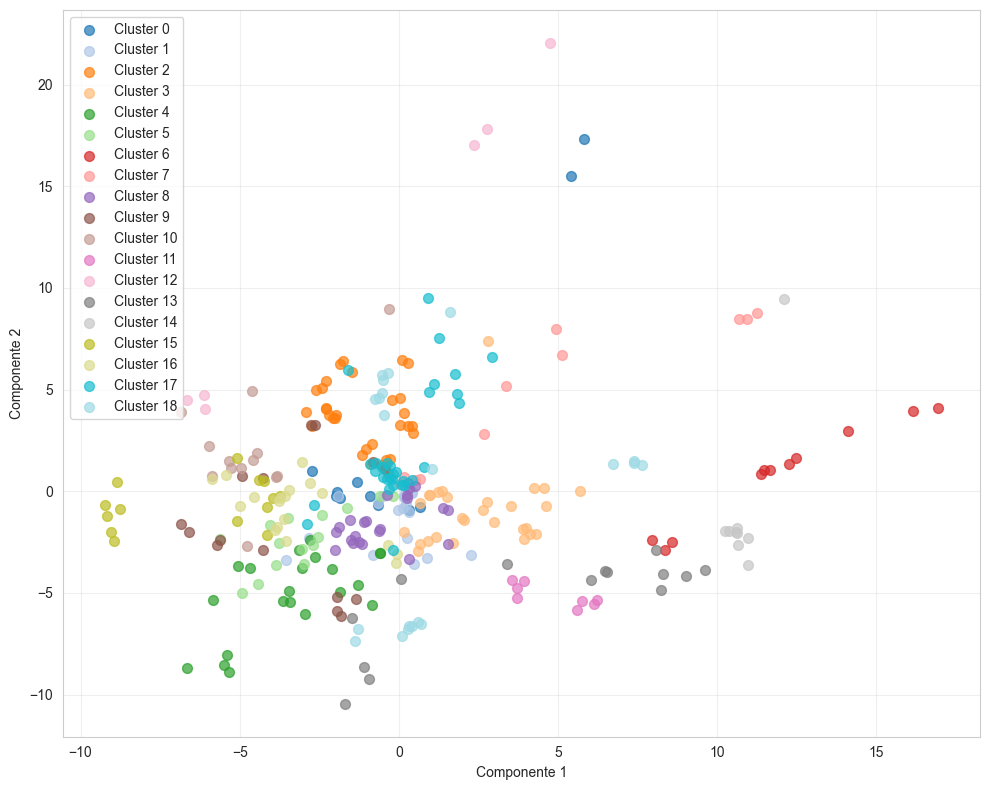

In [23]:
# reducimos a 2d usando PCA
best_assignments = gmm_results[19]["assignments"]
Z_2 = reducer_2d.encode(X_train_std, numpy=True)
plot_clusteres_2d(Z_2, best_assignments, xlabel="Componente 1", ylabel="Componente 2", filename="10_clustering_2d")

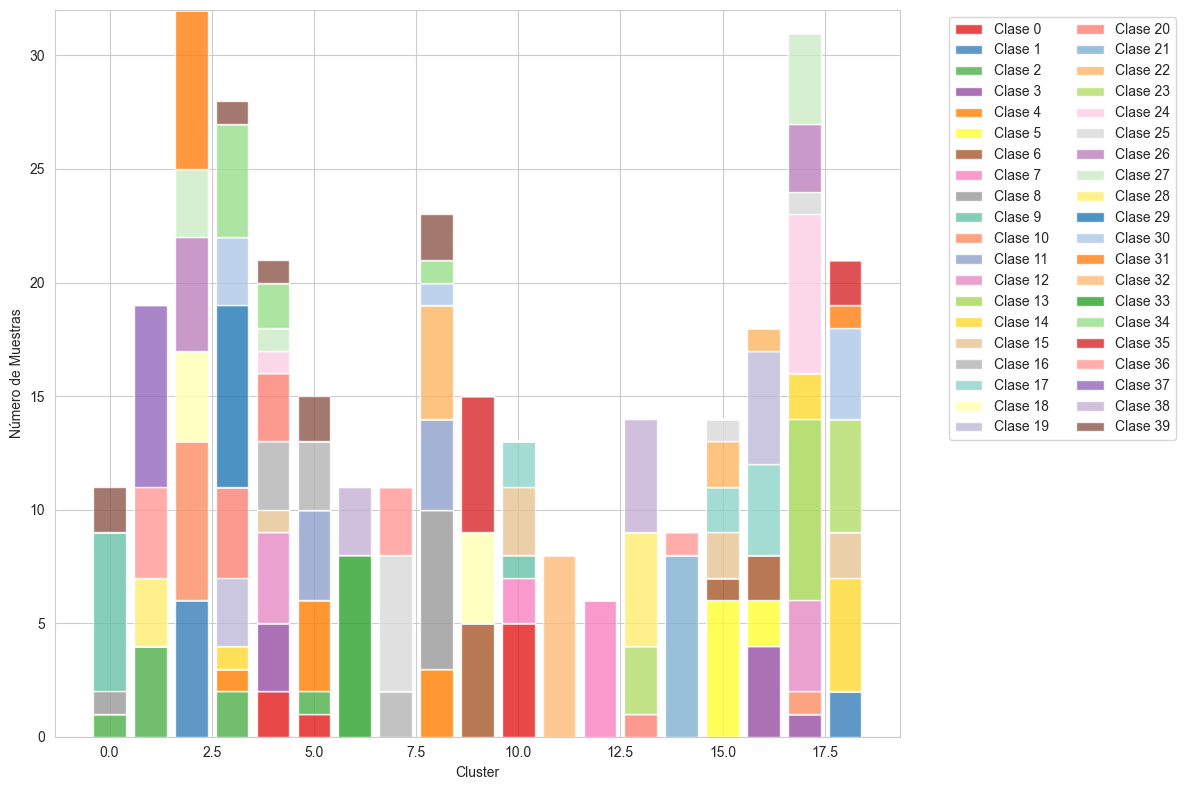

In [25]:
plot_cluster_composition(best_assignments, y_train, filename="11_cluster_composition")

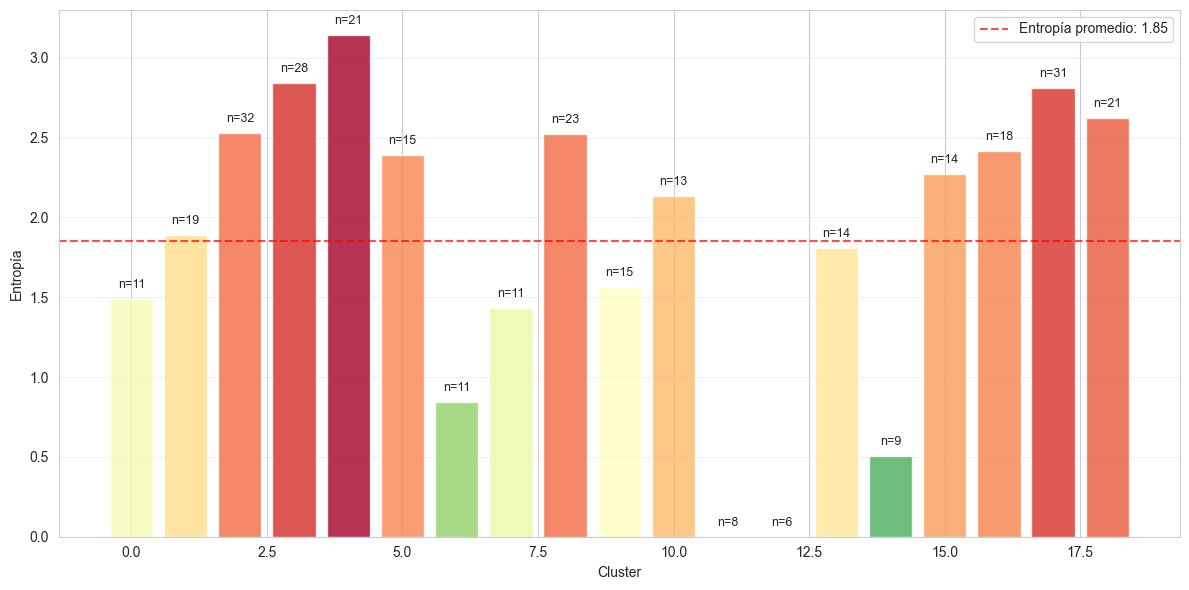

([np.float64(1.4911148494781075),
  np.float64(1.8924071180157986),
  np.float64(2.5257102525802058),
  np.float64(2.8388043679461874),
  np.float64(3.141619206741284),
  np.float64(2.3898980945986708),
  np.float64(0.8453509363338975),
  np.float64(1.4353713903417247),
  np.float64(2.5228657623948),
  np.float64(1.5655962299247932),
  np.float64(2.1339375653735693),
  np.float64(-1.4426951601859516e-10),
  np.float64(-1.4426951601859516e-10),
  np.float64(1.8092000321207338),
  np.float64(0.5032583344871068),
  np.float64(2.2709424208829203),
  np.float64(2.4138338631079836),
  np.float64(2.812055278231459),
  np.float64(2.6199707099177485)],
 [11, 19, 32, 28, 21, 15, 11, 11, 23, 15, 13, 8, 6, 14, 9, 14, 18, 31, 21])

In [26]:
plot_cluster_entropy(best_assignments, y_train, filename="12_cluster_entropy")

Experimento: samplear desde la distribución aprendida por GMM y pasar los samples por el decoder

In [27]:
def sample_from_gmm(means, covariances, priors, n_samples=1):
    samples = []

    for i in range(n_samples):
        component = np.random.choice(len(means), p=priors)
        sample = np.random.multivariate_normal(means[component], covariances[component])
        samples.append(sample)

    return np.array(samples)

samples_test = sample_from_gmm(gmm_results[19]["means"], gmm_results[19]["covariances"], gmm_results[19]["priors"], n_samples=5)

samples_test


array([[-2.13223733e+00, -5.77451843e+00, -2.31413409e+00,
         8.63145282e-01,  5.97910864e+00, -5.46244681e+00,
         3.09760740e+00,  5.78946520e-02,  5.73137437e+00,
        -4.41632242e-01,  2.91687490e+00, -7.49279252e+00,
        -9.64147887e+00,  7.04096617e+00,  4.38570118e+00,
        -5.94761179e+00,  1.09531743e+01,  3.58346749e+00,
         5.36619873e+00, -1.42047181e+00, -7.52829042e+00,
         2.61506324e+00,  3.47850004e+00,  1.35174509e+01,
        -1.07611355e+01,  4.20269873e+00,  6.81164013e+00,
         4.51440113e+00, -3.73667250e+00, -8.79665502e+00,
        -2.68681718e+00,  5.16651758e+00, -1.27378940e+01,
         4.28570374e+00, -7.45430346e+00,  6.78729670e+00,
        -8.52303758e+00, -7.27421524e+00, -8.01488520e+00,
         3.88651846e+00, -3.47421341e+00, -8.03598793e+00,
        -2.96876816e+00, -5.61571448e+00, -3.06010067e+00,
        -9.71685090e+00, -1.26193399e+00,  7.00774327e-01,
         3.55325693e+00,  3.77738440e+00,  1.20827421e+0

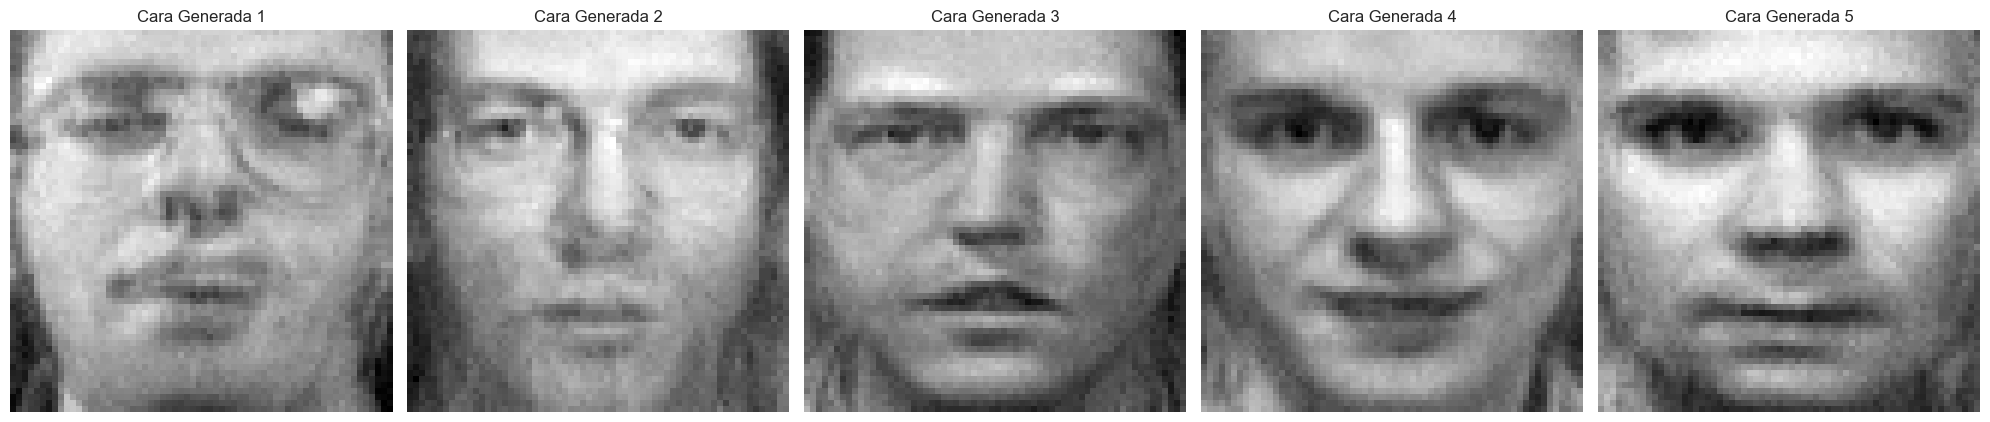

In [28]:

autoencoder.eval()
with torch.no_grad():
    decoded_samples = autoencoder.decode(samples_test, numpy=True) * X_train_sigma + X_train_mu

# Plotear
fig, axes = plt.subplots(1, 5, figsize=(20, 6))
for i in range(5):
    face = decoded_samples[i].reshape(64, 64)
    axes[i].imshow(face, cmap='gray')
    axes[i].set_title(f'Cara Generada {i+1}')
    axes[i].axis('off')
plt.tight_layout()
plt.savefig("plots/13_generated_faces.png")
plt.show()